Імпорти

In [2]:
import matplotlib.pyplot as plt
import numpy as np

Завантаження даних

In [16]:
train_data = np.genfromtxt(
    "lab_1_train.csv",
    delimiter=",",
    skip_header = 1
)

test_data = np.genfromtxt(
    "lab_1_test.csv",
    delimiter=",",
    skip_header = 1
)

x_train = train_data[:, 1]
y_train = train_data[:, 2]

x_test = test_data[:, 1]
y_test = test_data[:, 2]

print("Train size:", len(x_train))
print("Test size:", len(x_test))

Train size: 60
Test size: 40


Візуалізація даних 

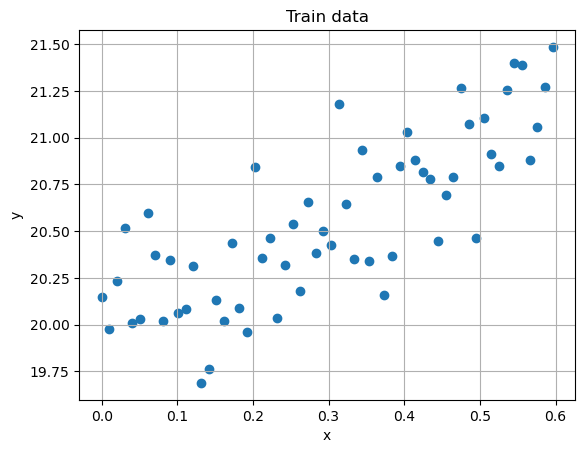

In [17]:
plt.scatter(x_train, y_train)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Train data")

plt.grid()
plt.show()

Функція передбачення

In [18]:
def predict(x, w0, w1):
    return w0 + w1 * x

Середньоквадратична помилка

In [19]:
def mse(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

Градієнтний спуск

In [20]:
def gradient_descent(x, y, learning_rate, max_epochs, epsilon):
    w0 = 0.0
    w1 = 0.0

    n = len(x)

    previous_loss = 0

    for epoch in range(max_epochs):
        y_pred = predict(x, w0, w1)

        error = y_pred - y

        loss = mse(y, y_pred)

        dw0 = (2 / n) * np.sum(error)
        dw1 = (2 / n) * np.sum(error * x)

        w0 = w0 - learning_rate * dw0
        w1 = w1 - learning_rate * dw1

        print(
            f"Епоха: {epoch + 1}, "
            f"w0: {w0:.6f}, "
            f"w1: {w1:.6f}, "
            f"MSE: {loss:.6f}"
        )

        if abs(previous_loss - loss) < epsilon:
            print()
            print("Градієнтний спуск зійшовся")
            print("Епоха:", epoch + 1)
            break

        previous_loss = loss

    return w0, w1

Навчання

In [54]:
w0, w1 = gradient_descent(x_train, y_train, learning_rate = 0.88, max_epochs = 1000, epsilon = 1e-9)
print()
print("Остаточні ваги:")
print("w0 =", w0)
print("w1 =", w1)
print(f"y = {w0:.6f} + {w1:.6f} * x")

Епоха: 1, w0: 36.167231, w1: 10.883676, MSE: 422.477402
Епоха: 2, w0: 2.972252, w1: 0.512651, MSE: 358.228731
Епоха: 3, w0: 33.639463, w1: 9.729822, MSE: 303.753802
Епоха: 4, w0: 5.498489, w1: 0.926932, MSE: 257.565665
Епоха: 5, w0: 31.502256, w1: 8.732179, MSE: 218.403603
Епоха: 6, w0: 7.645974, w1: 1.259771, MSE: 185.198713
Епоха: 7, w0: 29.695611, w1: 7.868841, MSE: 157.044716
Епоха: 8, w0: 9.471797, w1: 1.525332, MSE: 133.173219
Епоха: 9, w0: 28.168714, w1: 7.121057, MSE: 112.932730
Епоха: 10, w0: 11.024410, w1: 1.735453, MSE: 95.770879
Епоха: 11, w0: 26.878531, w1: 6.472766, MSE: 81.219331
Епоха: 12, w0: 12.344942, w1: 1.900017, MSE: 68.881001
Епоха: 13, w0: 25.788622, w1: 5.910205, MSE: 58.419218
Епоха: 14, w0: 13.468304, w1: 2.027264, MSE: 49.548528
Епоха: 15, w0: 24.868133, w1: 5.421572, MSE: 42.026904
Епоха: 16, w0: 14.424137, w1: 2.124054, MSE: 35.649140
Епоха: 17, w0: 24.090939, w1: 4.996741, MSE: 30.241245
Епоха: 18, w0: 15.237605, w1: 2.196088, MSE: 25.655701
Епоха: 19, w0

Перевірка моделі на тестових даних

In [55]:
test_predictions = predict(x_test, w0, w1)

test_loss = mse(y_test, test_predictions)

print("Test MSE:", test_loss)

Test MSE: 0.07556497047563167


Візуалізація результатів лінійної регресії

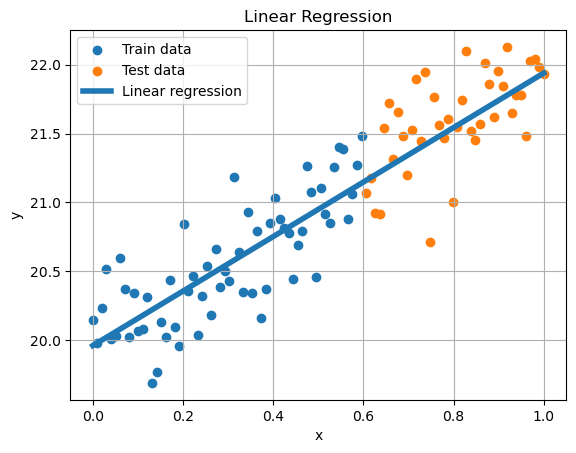

In [56]:
plt.scatter(
    x_train,
    y_train,
    label="Train data"
)

plt.scatter(
    x_test,
    y_test,
    label="Test data"
)

x_min = min(np.min(x_train), np.min(x_test))
x_max = max(np.max(x_train), np.max(x_test))

x_line = np.linspace(x_min, x_max, 100)

y_line = predict(x_line, w0, w1)

plt.plot(
    x_line,
    y_line,
    label="Linear regression",
    linewidth=4,
    zorder=4
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression")

plt.legend()
plt.grid()

plt.show()